In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

In [2]:
az.style.use("arviz-darkgrid")

## Polynomial regression

In [3]:
ans = pd.read_csv("../data/anscombe.csv")
ans.head()

,group,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


[Text(0.5, 0, 'x'), Text(0, 0.5, 'y')]

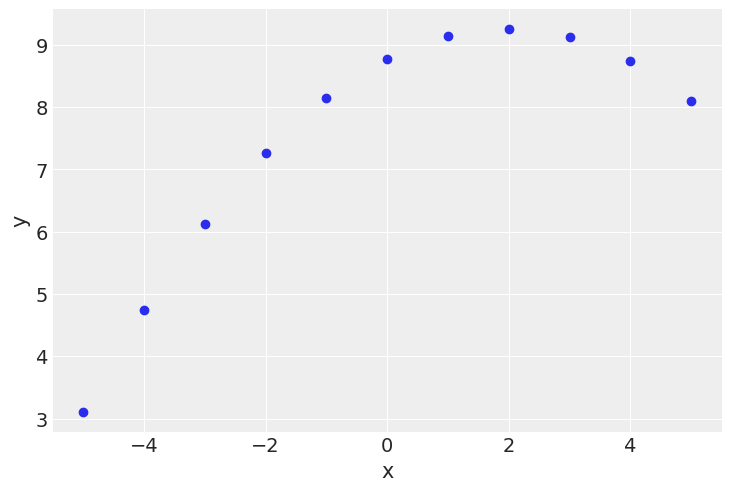

In [ ]:
x_2 = ans.query("group == 'II'")["x"].to_numpy().flatten()
y_2 = ans.query("group == 'II'")["y"].to_numpy().flatten()
x_2 = x_2 - x_2.mean()

_, ax = plt.subplots()
ax.scatter(x_2, y_2)
ax.set(xlabel="x", ylabel="y")

In [5]:
with pm.Model() as ans_poly:
    α_p = pm.Normal("α", mu=y_2.mean(), sigma=1)
    β1_p = pm.Normal("β1", mu=0, sigma=1)
    β2_p = pm.Normal("β2", mu=0, sigma=1)
    ε_p = pm.HalfCauchy("ϵ", 5)
    μ_p = α_p + β1_p * x_2 + β2_p * x_2**2
    y_pred_p = pm.Normal("y_pred", mu=μ_p, sigma=ε_p, observed=y_2)

    idata_poly = pm.sample(random_seed=123)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β1, β2, ϵ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


array([[<Axes: title={'center': 'α'}>, <Axes: title={'center': 'α'}>],
       [<Axes: title={'center': 'β1'}>, <Axes: title={'center': 'β1'}>],
       [<Axes: title={'center': 'β2'}>, <Axes: title={'center': 'β2'}>],
       [<Axes: title={'center': 'ϵ'}>, <Axes: title={'center': 'ϵ'}>]],
      dtype=object)

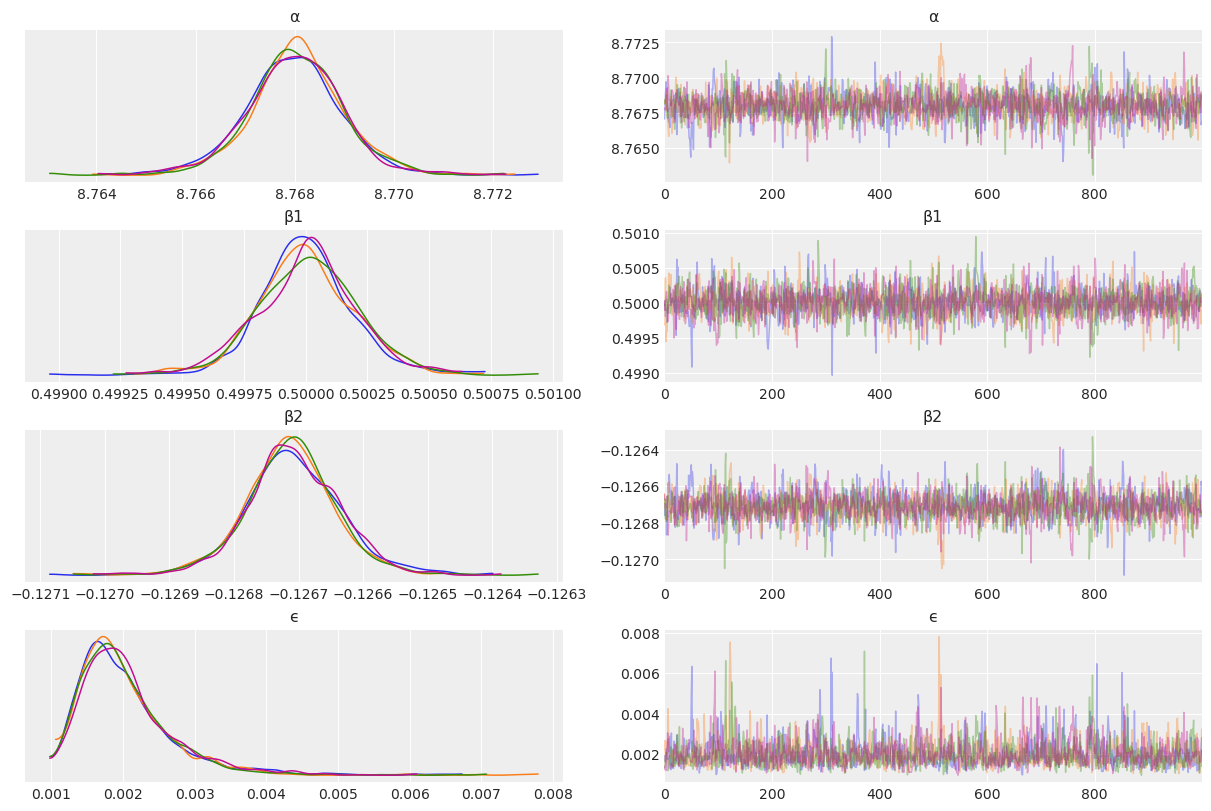

In [6]:
az.plot_trace(idata_poly, compact=False)

In [7]:
az.summary(idata_poly)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,8.768,0.001,8.766,8.770,0.0,0.0,1933.0,1830.0,1.0
β1,0.500,0.000,0.500,0.500,0.0,0.0,2245.0,1745.0,1.0
β2,-0.127,0.000,-0.127,-0.127,0.0,0.0,2129.0,2155.0,1.0
ϵ,0.002,0.001,0.001,0.003,0.0,0.0,1583.0,1554.0,1.0


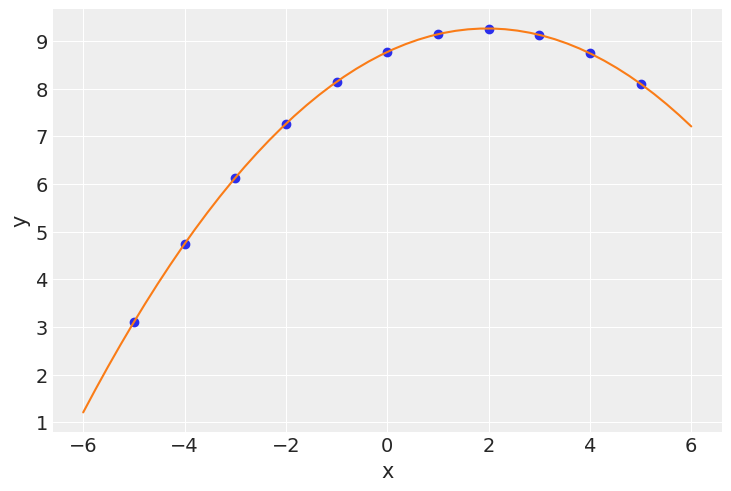

In [8]:
x_p = np.linspace(-6, 6)
α_m_2 = idata_poly.posterior["α"].mean().to_numpy().flatten()
β1_m = idata_poly.posterior["β1"].mean().to_numpy().flatten()
β2_m = idata_poly.posterior["β2"].mean().to_numpy().flatten()
y_p = α_m_2 + β1_m * x_p + β2_m * x_p**2
_, ax7 = plt.subplots()
ax7.scatter(x_2, y_2)
ax7.set(xlabel="x", ylabel="y")
ax7.plot(x_p, y_p, c="C1")